# EECS 498-007/598-005 Assignment 2-1: Linear Classifiers

Before we start, please put your name and UMID in following format

: Firstname LASTNAME, #00000000   //   e.g.) Justin JOHNSON, #12345678

**Your Answer:**   
Your NAME, #XXXXXXXX

## Setup Code
Before getting started, we need to run some boilerplate code to set up our environment, same as Assignment 1. You'll need to rerun this setup code each time you start the notebook.

First, run this cell load the autoreload extension. This allows us to edit .py source files, and re-import them into the notebook for a seamless editing and debugging experience.

In [1]:
%load_ext autoreload
%autoreload 2

# Data preprocessing

## Setup code
Run some setup code for this notebook: Import some useful packages and increase the default figure size.

In [2]:
import eecs598
import torch
import torchvision
import matplotlib.pyplot as plt
import statistics
import random
import time
import math
%matplotlib inline


plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['font.size'] = 16

Starting in this assignment, we will use the GPU to accelerate our computation. Run this cell to make sure you are using a GPU.

In [3]:
if torch.cuda.is_available:
  print('Good to go!')
else:
  print('Please set GPU via Edit -> Notebook Settings.')

Good to go!


## Load the CIFAR-10 dataset
Then, we will first load the CIFAR-10 dataset, same as knn. The utility function `eecs598.data.preprocess_cifar10()` returns the entire CIFAR-10 dataset as a set of six **Torch tensors**:

- `X_train` contains all training images (real numbers in the range $[0, 1]$)
- `y_train` contains all training labels (integers in the range $[0, 9]$)
- `X_val` contains all validation images
- `y_val` contains all validation labels
- `X_test` contains all test images
- `y_test` contains all test labels

In this notebook we will use the **bias trick**: By adding an extra constant feature of ones to each image, we avoid the need to keep track of a bias vector; the bias will be encoded as the part of the weight matrix that interacts with the constant ones in the input.

In the `two_layer_net.ipynb` notebook that follows this one, we will not use the bias trick.

We can learn more about the `eecs598.data.preprocess_cifar10` function by invoking the `help` command:

In [4]:
import eecs598
help(eecs598.data.preprocess_cifar10)

Help on function preprocess_cifar10 in module eecs598.data:

preprocess_cifar10(cuda=True, show_examples=True, bias_trick=False, flatten=True, validation_ratio=0.2, dtype=torch.float32)
    Returns a preprocessed version of the CIFAR10 dataset, automatically
    downloading if necessary. We perform the following steps:
    
    (0) [Optional] Visualize some images from the dataset
    (1) Normalize the data by subtracting the mean
    (2) Reshape each image of shape (3, 32, 32) into a vector of shape (3072,)
    (3) [Optional] Bias trick: add an extra dimension of ones to the data
    (4) Carve out a validation set from the training set
    
    Inputs:
    - cuda: If true, move the entire dataset to the GPU
    - validation_ratio: Float in the range (0, 1) giving the fraction of the train
      set to reserve for validation
    - bias_trick: Boolean telling whether or not to apply the bias trick
    - show_examples: Boolean telling whether or not to visualize data samples
    - dtype:

We can now run the `eecs598.data.preprocess` function to get our data:

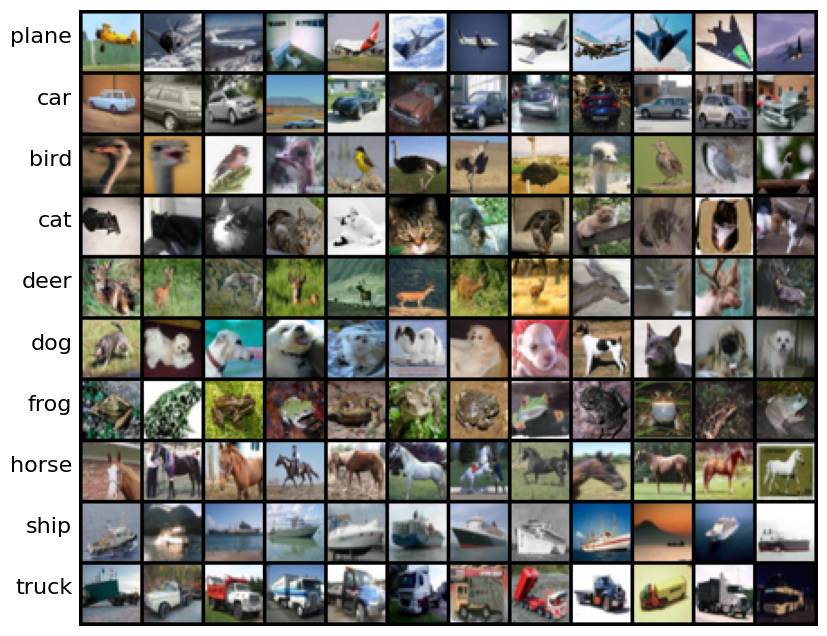

Train data shape:  torch.Size([40000, 3073])
Train labels shape:  torch.Size([40000])
Validation data shape:  torch.Size([10000, 3073])
Validation labels shape:  torch.Size([10000])
Test data shape:  torch.Size([10000, 3073])
Test labels shape:  torch.Size([10000])


In [5]:
# Invoke the above function to get our data. 
import eecs598

eecs598.reset_seed(0)
data_dict = eecs598.data.preprocess_cifar10(bias_trick=True, cuda=True, dtype=torch.float64)
print('Train data shape: ', data_dict['X_train'].shape)
print('Train labels shape: ', data_dict['y_train'].shape)
print('Validation data shape: ', data_dict['X_val'].shape)
print('Validation labels shape: ', data_dict['y_val'].shape)
print('Test data shape: ', data_dict['X_test'].shape)
print('Test labels shape: ', data_dict['y_test'].shape)

# SVM Classifier

In this section, you will:
    
- implement a fully-vectorized **loss function** for the SVM
- implement the fully-vectorized expression for its **analytic gradient**
- **check your implementation** using numerical gradient
- use a validation set to **tune the learning rate and regularization** strength
- **optimize** the loss function with **SGD**
- **visualize** the final learned weights

In Assignment 2, you SHOULD NOT use ".to()" or ".cuda()" in each implementation block. Otherwise, your implementation would gives you an error in Autograder end.

First, we will test the naive version of svm loss in `linear_classifier.py`. Let's first try the naive implementation of the loss we provided for you. You will get 9.000197. (Note: we've provided the `loss` part of the `svm_loss_naive` function, so you don't need to re-implement in `svm_loss_naive`. However, if your loss value doesn't match, then please report this to [Piazza](https://piazza.com/class/kxtai72amx34p0))

In [6]:
import eecs598
from linear_classifier import svm_loss_naive

eecs598.reset_seed(0)
# generate a random SVM weight tensor of small numbers
W = torch.randn(3073, 10, dtype=data_dict['X_val'].dtype, device=data_dict['X_val'].device) * 0.0001 

loss, _grad_ = svm_loss_naive(W, data_dict['X_val'], data_dict['y_val'], 0.000005)
print('loss: %f' % (loss, ))

loss: 9.000888


The `_grad_` returned from the function above is right now all zero. Derive and implement the gradient for the SVM cost function and implement it inline inside the function `svm_loss_naive`, by filing out the TODO blocks. You will find it helpful to interweave your new code inside the existing function.

To check that you have implemented the gradient correctly, we will use **numeric gradient checking**: we will use a finite differences approach to numerically estimate the gradient of the forward pass, and compare this numeric gradient to the analytic gradient that you implemented.

We have provided a function `eecs598.grad.grad_check_sparse` to help with numeric gradient checking. You can learn more about this function using the `help` command:

In [7]:
import eecs598
help(eecs598.grad.grad_check_sparse)

Help on function grad_check_sparse in module eecs598.grad:

grad_check_sparse(f, x, analytic_grad, num_checks=10, h=1e-07)
    Utility function to perform numeric gradient checking. We use the centered
    difference formula to compute a numeric derivative:
    
    f'(x) =~ (f(x + h) - f(x - h)) / (2h)
    
    Rather than computing a full numeric gradient, we sparsely sample a few
    dimensions along which to compute numeric derivatives.
    
    Inputs:
    - f: A function that inputs a torch tensor and returns a torch scalar
    - x: A torch tensor of the point at which to evaluate the numeric gradient
    - analytic_grad: A torch tensor giving the analytic gradient of f at x
    - num_checks: The number of dimensions along which to check
    - h: Step size for computing numeric derivatives



Now run the following to perform numeric gradient checking on the gradients of your SVM loss. You should see relative errors less than `1e-5`.

In [8]:
import eecs598
from linear_classifier import svm_loss_naive

# Once you've implemented the gradient, recompute it with the code below
# and gradient check it with the function we provided for you

# Use a random W and a minibatch of data from the val set for gradient checking
# For numeric gradient checking it is a good idea to use 64-bit floating point
# numbers for increased numeric precision; however when actually training models
# we usually use 32-bit floating point numbers for increased speed.
eecs598.reset_seed(0)
W = 0.0001 * torch.randn(3073, 10, dtype=data_dict['X_val'].dtype, device=data_dict['X_val'].device)
batch_size = 64
X_batch = data_dict['X_val'][:batch_size]
y_batch = data_dict['y_val'][:batch_size]

# Compute the loss and its gradient at W.
# YOUR_TURN: implement the gradient part of 'svm_loss_naive' function in "linear_classifier.py"
_, grad = svm_loss_naive(W, X_batch, y_batch, reg=0.0)

# Numerically compute the gradient along several randomly chosen dimensions, and
# compare them with your analytically computed gradient. The numbers should
# match almost exactly along all dimensions.
f = lambda w: svm_loss_naive(w, X_batch, y_batch, reg=0.0)[0]
grad_numerical = eecs598.grad.grad_check_sparse(f, W, grad)

numerical: 0.031599 analytic: 0.031599, relative error: 3.139148e-07
numerical: 0.111444 analytic: 0.111444, relative error: 9.893848e-10
numerical: 0.011204 analytic: 0.011204, relative error: 1.003052e-06
numerical: -0.046128 analytic: -0.046128, relative error: 1.470228e-08
numerical: 0.071948 analytic: 0.071948, relative error: 1.000117e-07
numerical: 0.025688 analytic: 0.025688, relative error: 1.051337e-06
numerical: 0.185388 analytic: 0.185388, relative error: 7.039118e-09
numerical: -0.021740 analytic: -0.021740, relative error: 3.369463e-07
numerical: -0.159613 analytic: -0.159613, relative error: 6.416943e-08
numerical: 0.092690 analytic: 0.092690, relative error: 1.748534e-07


Let's do the gradient check once again with regularization turned on. (You didn't forget the regularization gradient, did you?)

You should see relative errors less than `1e-5`.

In [9]:
import eecs598
from linear_classifier import svm_loss_naive

# Use a minibatch of data from the val set for gradient checking
eecs598.reset_seed(0)
W = 0.0001 * torch.randn(3073, 10, dtype=data_dict['X_val'].dtype, device=data_dict['X_val'].device)
batch_size = 64
X_batch = data_dict['X_val'][:batch_size]
y_batch = data_dict['y_val'][:batch_size]

# Compute the loss and its gradient at W.
# YOUR_TURN: check your 'svm_loss_naive' implementation with different 'reg'
_, grad = svm_loss_naive(W, X_batch, y_batch, reg=1e3) 

# Numerically compute the gradient along several randomly chosen dimensions, and
# compare them with your analytically computed gradient. The numbers should
# match almost exactly along all dimensions.
f = lambda w: svm_loss_naive(w, X_batch, y_batch, reg=1e3)[0]
grad_numerical = eecs598.grad.grad_check_sparse(f, W, grad)

numerical: 0.124849 analytic: 0.124849, relative error: 6.251581e-08
numerical: 0.168915 analytic: 0.168915, relative error: 5.957873e-09
numerical: 0.148752 analytic: 0.148752, relative error: 8.733009e-08
numerical: -0.024936 analytic: -0.024936, relative error: 1.133872e-07
numerical: -0.008570 analytic: -0.008570, relative error: 7.174549e-07
numerical: -0.103155 analytic: -0.103155, relative error: 2.498757e-07
numerical: -0.335573 analytic: -0.335573, relative error: 4.472387e-09
numerical: -0.222176 analytic: -0.222176, relative error: 4.264915e-08
numerical: 0.681163 analytic: 0.681163, relative error: 1.235571e-08
numerical: -0.004090 analytic: -0.004089, relative error: 4.327973e-06


Now, let's implement vectorized version of SVM: `svm_loss_vectorized`. It should compute the same inputs and outputs as the naive version before, but it should involve **no explicit loops**.

Let's first check the speed and performance bewteen the non-vectorized and the vectorized version. You should see a 15-120x speedup. PyTorch does some extra setup the first time you run CUDA code, so **you may need to run this cell more than once to see the desired speedup**.

(Note: It may have some difference, but should be less than 1e-6)

In [10]:
import eecs598
from linear_classifier import svm_loss_naive, svm_loss_vectorized

# Use random weights and a minibatch of val data for gradient checking
eecs598.reset_seed(0)
W = 0.0001 * torch.randn(3073, 10, dtype=data_dict['X_val'].dtype, device=data_dict['X_val'].device)
X_batch = data_dict['X_val'][:128]
y_batch = data_dict['y_val'][:128]
reg = 0.000005

# Run and time the naive version
torch.cuda.synchronize()
tic = time.time()
loss_naive, grad_naive = svm_loss_naive(W, X_batch, y_batch, reg)
torch.cuda.synchronize()
toc = time.time()
ms_naive = 1000.0 * (toc - tic)
print('Naive loss: %e computed in %.2fms' % (loss_naive, ms_naive))

# Run and time the vectorized version
torch.cuda.synchronize()
tic = time.time()
# YOUR_TURN: implement the loss part of 'svm_loss_vectorized' function in "linear_classifier.py"
loss_vec, _ = svm_loss_vectorized(W, X_batch, y_batch, reg)
torch.cuda.synchronize()
toc = time.time()
ms_vec = 1000.0 * (toc - tic)
print('Vectorized loss: %e computed in %.2fms' % (loss_vec, ms_vec))

# The losses should match but your vectorized implementation should be much faster.
print('Difference: %.2e' % (loss_naive - loss_vec))
print('Speedup: %.2fX' % (ms_naive / ms_vec))

Naive loss: 9.002394e+00 computed in 342.22ms
Vectorized loss: 9.002394e+00 computed in 93.09ms
Difference: -5.33e-15
Speedup: 3.68X


Then, let's compute the gradient of the loss function. We can check the difference of gradient as well. (The error should be less than 1e-6)

Now implement a vectorized version of the gradient computation in `svm_loss_vectorize` above. Run the cell below to compare the gradient of your naive and vectorized implementations. The difference between the gradients should be less than `1e-6`, and the vectorized version should run 15-120x faster.


In [11]:
# The naive implementation and the vectorized implementation should match, but
# the vectorized version should still be much faster.
import torch
import eecs598
from linear_classifier import svm_loss_naive, svm_loss_vectorized

# Use random weights and a minibatch of val data for gradient checking


eecs598.reset_seed(0)
W = 0.0001 * torch.randn(3073, 10, dtype=data_dict['X_val'].dtype, device=data_dict['X_val'].device)
X_batch = data_dict['X_val'][:128]
y_batch = data_dict['y_val'][:128]
reg = 0.000005

# Run and time the naive version
torch.cuda.synchronize()
tic = time.time()
_, grad_naive = svm_loss_naive(W, X_batch, y_batch, 0.000005)
torch.cuda.synchronize()
toc = time.time()
ms_naive = 1000.0 * (toc - tic)
print('Naive loss and gradient: computed in %.2fms' % ms_naive)

# Run and time the vectorized version
torch.cuda.synchronize()
tic = time.time()
# YOUR_TURN: implement the gradient part of 'svm_loss_vectorized' function in "linear_classifier.py"
_, grad_vec = svm_loss_vectorized(W, X_batch, y_batch, 0.000005)
torch.cuda.synchronize()
toc = time.time()
ms_vec = 1000.0 * (toc - tic)
print('Vectorized loss and gradient: computed in %.2fms' % ms_vec)

# The loss is a single number, so it is easy to compare the values computed
# by the two implementations. The gradient on the other hand is a tensor, so
# we use the Frobenius norm to compare them.
grad_difference = torch.norm(grad_naive - grad_vec, p='fro')
print('Gradient difference: %.2e' % grad_difference)
print('Speedup: %.2fX' % (ms_naive / ms_vec))

Naive loss and gradient: computed in 418.33ms
Vectorized loss and gradient: computed in 1.00ms
Gradient difference: 1.82e-14
Speedup: 418.06X


Now that we have an efficient vectorized implementation of the SVM loss and its gradient, we can implement a training pipeline for linear classifiers.

Please complete the implementation of `train_linear_classifier` in `linear_classifer.py`.


Once you have implemented the training function, run the following cell to train a linear classifier using some default hyperparameters:

(You should see a final loss close to 9.0, and your training loop should run in about two seconds)

In [12]:
import eecs598
from linear_classifier import svm_loss_vectorized, train_linear_classifier

# 固定随机数种子，保证结果可复现
eecs598.reset_seed(0)

# GPU 同步，确保之前的运算完成；开始计时
torch.cuda.synchronize()
tic = time.time()

# 调用训练函数
# TODO: 需要你在 train_linear_classifier 里实现：
#  (1) 如何构造 batch（sample_batch）
#  (2) 如何更新权重 W
W, loss_hist = train_linear_classifier(
    svm_loss_vectorized,     # 使用向量化 SVM 损失函数
    None,                    # 不传入初始 W，让函数内部初始化
    data_dict['X_train'],    # 训练数据 (N, D)
    data_dict['y_train'],    # 训练标签 (N,)
    learning_rate=3e-11,     # 学习率
    reg=2.5e4,               # 正则化强度
    num_iters=1500,          # 迭代次数
    verbose=True             # 每 100 次打印一次 loss
)

# 再次 GPU 同步，结束计时
torch.cuda.synchronize()
toc = time.time()

# 打印总耗时
print('That took %fs' % (toc - tic))


iteration 0 / 1500: loss 9.000786
iteration 100 / 1500: loss 9.000786
iteration 200 / 1500: loss 9.000760
iteration 300 / 1500: loss 9.000784
iteration 400 / 1500: loss 9.000769
iteration 500 / 1500: loss 9.000767
iteration 600 / 1500: loss 9.000750
iteration 700 / 1500: loss 9.000763
iteration 800 / 1500: loss 9.000778
iteration 900 / 1500: loss 9.000765
iteration 1000 / 1500: loss 9.000778
iteration 1100 / 1500: loss 9.000772
iteration 1200 / 1500: loss 9.000776
iteration 1300 / 1500: loss 9.000764
iteration 1400 / 1500: loss 9.000773
That took 1.243726s


A useful debugging strategy is to plot the loss as a function of iteration number. In this case it seems our hyperparameters are not good, since the training loss is not decreasing very fast.



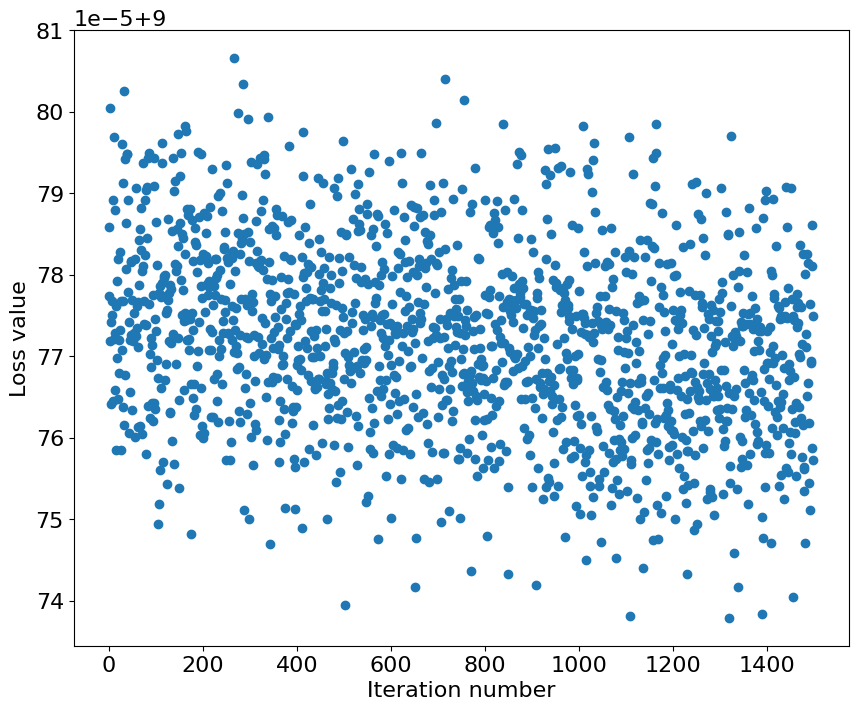

In [13]:
plt.plot(loss_hist, 'o')
plt.xlabel('Iteration number')
plt.ylabel('Loss value')
plt.show()

Then, let's move on to the prediction stage. We can evaluate the performance our trained model on both the training and validation set. You should see validation accuracy less than 20%.                                
然后，让我们进入预测阶段。我们可以评估训练模型在训练集和验证集上的性能。您应该看到验证准确率低于 20%。

In [14]:
import eecs598
from linear_classifier import predict_linear_classifier

# fix random seed before we perform this operation 在执行此作之前修复随机种子
eecs598.reset_seed(0)

# evaluate the performance on both the training and validation set 评估训练集和验证集的性能
# YOUR_TURN: Implement how to make a prediction with the trained weight 实现如何使用训练的权重进行预测
#            in 'predict_linear_classifier'
y_train_pred = predict_linear_classifier(W, data_dict['X_train'])
train_acc = 100.0 * (data_dict['y_train'] == y_train_pred).double().mean().item()
print('Training accuracy: %.2f%%' % train_acc)

y_val_pred = predict_linear_classifier(W, data_dict['X_val'])
val_acc = 100.0 * (data_dict['y_val'] == y_val_pred).double().mean().item()
print('Validation accuracy: %.2f%%' % val_acc)

Training accuracy: 9.24%
Validation accuracy: 9.01%


Unfortunately, the performance of our initial model is quite bad. To find a better hyperparamters, we first modulized the functions that we've implemented as LinearSVM.               
不幸的是，我们初始模型的性能非常糟糕。为了找到更好的超参数，我们首先对我们实现为 LinearSVM 的函数进行了模制。

Now, please use the validation set to tune hyperparameters (regularization strength and learning rate). You should experiment with different ranges for the learning rates and regularization strengths.

To get full credit for the assignment your best model found through cross-validation should achieve an accuracy of at least 37% on the validation set.

(Our best model got over 38.1% -- did you beat us?)

现在，请使用验证集来调整超参数（正则化强度和学习率）。您应该尝试不同的学习率和正则化强度范围。

要获得分配的全部学分，通过交叉验证找到的最佳模型应在验证集上达到至少 37% 的准确率。

（我们最好的模型获得了超过 38.1% 的成绩——你打败了我们吗？

In [20]:
import os
import eecs598
from linear_classifier import LinearSVM, svm_get_search_params, test_one_param_set

# YOUR_TURN: find the best learning_rates and regularization_strengths combination
#            in 'svm_get_search_params'
# 你的任务：在 'svm_get_search_params' 中找到最佳的学习率 (learning_rates) 和正则化强度 (regularization_strengths) 组合
learning_rates, regularization_strengths = svm_get_search_params()
num_models = len(learning_rates) * len(regularization_strengths)

####
# It is okay to comment out the following conditions when you are working on svm_get_search_params.
# But, please do not forget to reset back to the original setting once you are done.
# 在调试 svm_get_search_params 时，你可以注释掉以下条件判断。
# 但是，请务必在完成后恢复原始设置。
if num_models > 25:
  raise Exception("Please do not test/submit more than 25 items at once")
elif num_models < 5:
  raise Exception("Please present at least 5 parameter sets in your final ipynb")
####


i = 0
# results is dictionary mapping tuples of the form
# (learning_rate, regularization_strength) to tuples of the form
# (train_acc, val_acc). 
# results 是一个字典，将 (learning_rate, regularization_strength) 映射到 (train_acc, val_acc) 的元组。
results = {}
best_val = -1.0   # The highest validation accuracy that we have seen so far.
                  # 目前为止我们得到的最高验证准确率。
best_svm_model = None # The LinearSVM object that achieved the highest validation rate.
                      # 达到最高验证准确率的 LinearSVM 对象。
num_iters = 2000 # number of iterations
                 # 迭代次数

for lr in learning_rates:
  for reg in regularization_strengths:
    i += 1
    print('Training SVM %d / %d with learning_rate=%e and reg=%e'
          % (i, num_models, lr, reg))
    
    eecs598.reset_seed(0)
    # YOUR_TURN: implement a function that gives the trained model with 
    #            train/validation accuracies in 'test_one_param_set'
    #            (note: this function will be used in Softmax Classifier section as well)
    # 你的任务：实现 'test_one_param_set' 函数，它返回训练好的模型及其训练/验证准确率
    # （注意：这个函数在 Softmax 分类器部分也会用到）
    cand_svm_model, cand_train_acc, cand_val_acc = test_one_param_set(LinearSVM(), data_dict, lr, reg, num_iters)

    if cand_val_acc > best_val:

      best_val = cand_val_acc
      best_svm_model = cand_svm_model # save the svm
                                     # 保存当前最优的 SVM 模型
    results[(lr, reg)] = (cand_train_acc, cand_val_acc)


# Print out results.
# 输出结果
for lr, reg in sorted(results):
  train_acc, val_acc = results[(lr, reg)]
  print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
         lr, reg, train_acc, val_acc))
    
print('best validation accuracy achieved during cross-validation: %f' % best_val)
# 输出交叉验证过程中获得的最佳验证准确率

# save the best model
# 保存最优模型

path = os.path.join(os.getcwd() ,'svm_best_model.pt')
best_svm_model.save(path)


Training SVM 1 / 25 with learning_rate=1.000000e-04 and reg=1.000000e-05
Training SVM 2 / 25 with learning_rate=1.000000e-04 and reg=1.000000e-04
Training SVM 3 / 25 with learning_rate=1.000000e-04 and reg=1.000000e-03
Training SVM 4 / 25 with learning_rate=1.000000e-04 and reg=1.000000e-02
Training SVM 5 / 25 with learning_rate=1.000000e-04 and reg=1.000000e-01
Training SVM 6 / 25 with learning_rate=3.000000e-04 and reg=1.000000e-05
Training SVM 7 / 25 with learning_rate=3.000000e-04 and reg=1.000000e-04
Training SVM 8 / 25 with learning_rate=3.000000e-04 and reg=1.000000e-03
Training SVM 9 / 25 with learning_rate=3.000000e-04 and reg=1.000000e-02
Training SVM 10 / 25 with learning_rate=3.000000e-04 and reg=1.000000e-01
Training SVM 11 / 25 with learning_rate=1.000000e-03 and reg=1.000000e-05
Training SVM 12 / 25 with learning_rate=1.000000e-03 and reg=1.000000e-04
Training SVM 13 / 25 with learning_rate=1.000000e-03 and reg=1.000000e-03
Training SVM 14 / 25 with learning_rate=1.00000

Visualize the cross-validation results. You can use this as a debugging tool -- after examining the cross-validation results here, you may want to go back and rerun your cross-validation from above.          
可视化交叉验证结果。您可以将其用作调试工具 -- 在检查此处的交叉验证结果后，您可能希望返回并从上面重新运行交叉验证。


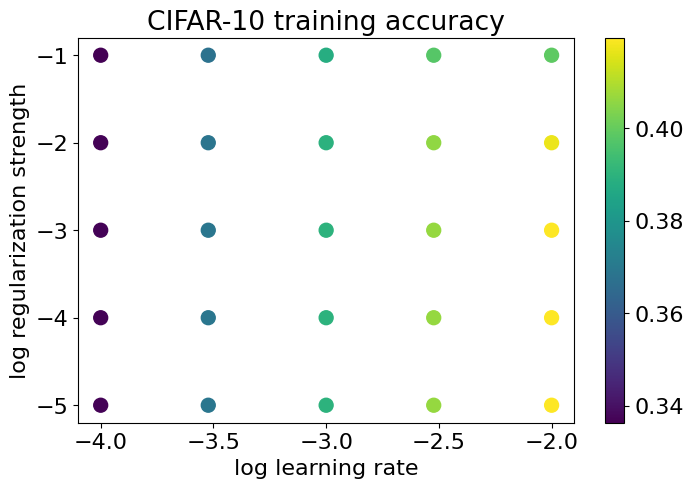

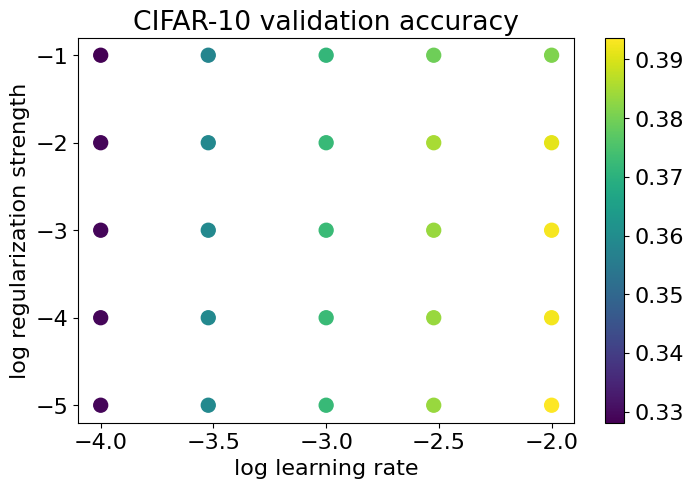

In [21]:
# x_scatter 和 y_scatter 是绘制散点图的 x 和 y 坐标，这里对结果进行 log10 变换
x_scatter = [math.log10(x[0]) for x in results]  # 将每个结果的第一个值（学习率）取对数作为 x 坐标
y_scatter = [math.log10(x[1]) for x in results]  # 将每个结果的第二个值（正则化强度）取对数作为 y 坐标

# =========================
# 绘制训练集准确率散点图
# =========================
marker_size = 100  # 设置散点大小
colors = [results[x][0] for x in results]  # 使用结果中的第一个值（通常是训练准确率）作为颜色映射
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap='viridis')  # 绘制散点图，c表示颜色，cmap指定颜色映射
plt.colorbar()  # 显示颜色条，说明颜色对应的数值
plt.xlabel('log learning rate')  # x轴标签
plt.ylabel('log regularization strength')  # y轴标签
plt.title('CIFAR-10 training accuracy')  # 图表标题
plt.gcf().set_size_inches(8, 5)  # 设置图像大小为 8x5 英寸
plt.show()  # 显示图像

# =========================
# 绘制验证集准确率散点图
# =========================
colors = [results[x][1] for x in results]  # 使用结果中的第二个值（通常是验证准确率）作为颜色映射
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap='viridis')  # 绘制散点图
plt.colorbar()  # 显示颜色条
plt.xlabel('log learning rate')  # x轴标签
plt.ylabel('log regularization strength')  # y轴标签
plt.title('CIFAR-10 validation accuracy')  # 图表标题
plt.gcf().set_size_inches(8, 5)  # 设置图像大小
plt.show()  # 显示图像


Evaluate the best svm on test set. To get full credit for the assignment you should achieve a test-set accuracy above 35%.

(Our best was over 39.1% -- did you beat us?)          
评估测试集上的最佳 SVM。要获得作业的满分，您应该达到 35% 以上的测试集准确率。

（我们的最好成绩超过 39.1% ——你打败了我们吗？

In [23]:
import eecs598  # 导入自定义模块 eecs598，可能包含一些工具函数或设置

# =========================
# 设置随机种子
# =========================
eecs598.reset_seed(0)  
# 调用模块中的 reset_seed 函数，将随机数生成器的种子固定为 0
# 这样每次运行代码时，生成的随机数都相同，保证实验可复现

# =========================
# 使用训练好的 SVM 模型进行测试集预测
# =========================
y_test_pred = best_svm_model.predict(data_dict['X_test'])  
# 调用 SVM 模型的 predict 方法，对测试集 X_test 进行预测
# 返回的 y_test_pred 是模型预测的标签

# =========================
# 计算测试集准确率
# =========================
test_accuracy = torch.mean((data_dict['y_test'] == y_test_pred).double())  
# 首先比较预测结果和真实标签，得到布尔张量 (True/False)
# 然后用 .double() 转成浮点数 (True→1.0, False→0.0)
# 最后用 torch.mean() 求平均值，即得到测试集准确率

# =========================
# 输出测试集准确率
# =========================
print('linear SVM on raw pixels final test set accuracy: %f' % test_accuracy)  
# 打印最终测试集准确率


linear SVM on raw pixels final test set accuracy: 0.393800


Visualize the learned weights for each class. Depending on your choice of learning rate and regularization strength, these may or may not be nice to look at.        
可视化每个类的学习权重。根据您选择的学习率和正则化强度，这些可能看起来不错，也可能不太好看。

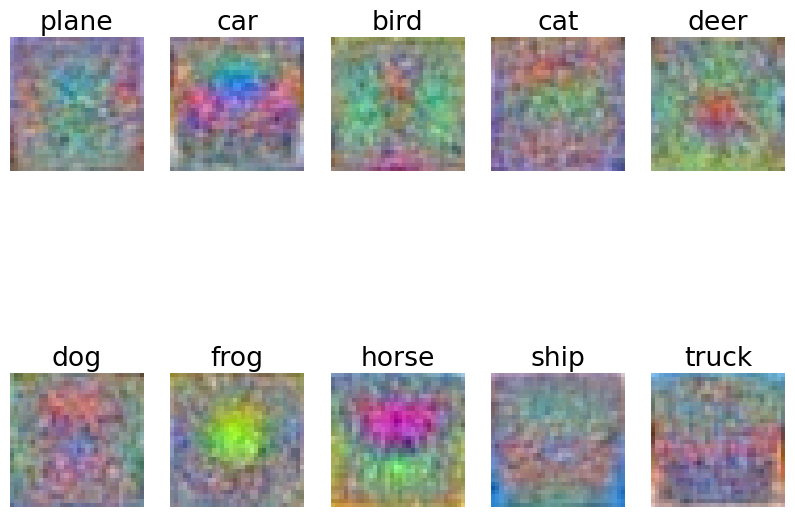

In [ ]:
# =========================
# 可视化训练好的 SVM 模型权重
# =========================

w = best_svm_model.W[:-1,:]  # 去掉最后一行偏置项，只保留权重矩阵
w = w.reshape(3, 32, 32, 10)  # 将权重重塑为 (通道数, 高, 宽, 类别数) 这里是 RGB 3 通道，32x32 图片，10 类
w = w.transpose(0, 2).transpose(1, 0)  #交换维度
# 调整维度顺序，使得权重可以按 (高, 宽, 通道, 类别) 的形式显示
# 这两次 transpose 是为了符合 plt.imshow 的输入格式 (H, W, C)

# =========================
# 找到权重的最小值和最大值，用于归一化显示
# =========================
w_min, w_max = torch.min(w), torch.max(w)

# 定义 CIFAR-10 类别名称
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

# =========================
# 遍历每个类别，将对应权重可视化为图片
# =========================
for i in range(10):
  plt.subplot(2, 5, i + 1)  # 将 10 张图片排成 2 行 5 列的子图

  # 将权重归一化到 [0, 255]，方便显示为灰度/彩色图像   三通道所以彩色
  wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)  #squeeze()默认去掉大小为1的维度  或指定目录的维度

  # 显示权重图像
  plt.imshow(wimg.type(torch.uint8).cpu())  # 转成 uint8 类型，并移到 CPU 上显示
  plt.axis('off')  # 去掉坐标轴
  plt.title(classes[i])  # 设置每张子图的标题为对应类别


# Softmax Classifier

Similar to the SVM, you will:

- implement a fully-vectorized **loss function** for the Softmax classifier
- implement the fully-vectorized expression for its **analytic gradient**
- **check your implementation** with numerical gradient
- use a validation set to **tune the learning rate and regularization** strength
- **optimize** the loss function with **SGD**
- **visualize** the final learned weights

As noted in the SVM section, you SHOULD NOT use ".to()" or ".cuda()" in each implementation block.


# Softmax 分类器

与 SVM 类似，您将：

- 为 Softmax 分类器实现完全矢量化的 **损失函数**
- 实现其**解析梯度**的完全矢量化表达式
- **使用数字梯度检查您的实现**
- 使用验证集来**调整学习率和正则化**强度
- **优化**使用 **SGD** 的损失函数
- **可视化** 最终学习的权重

如 SVM 部分所述，您不应在每个实现块中使用“.to（）”或“.cuda（）”。

First, let's start from implementing the naive softmax loss function with nested loops in `softmax_loss_naive` function.   
首先，让我们从实现在“softmax_loss_naive”函数中带有嵌套循环的朴素软最大损失函数开始。

As a sanity check to see whether we have implemented the loss correctly, run the softmax classifier with a small random weight matrix and no regularization. You should see loss near log(10) = 2.3             
作为健全性检查，看看我们是否正确地实现了损失，运行具有较小随机权重矩阵且没有正则化的 softmax 分类器。您应该在 log（10） = 2.3 附近看到损失

In [30]:
import eecs598  # 导入自定义模块 eecs598
from linear_classifier import softmax_loss_naive  # 从 linear_classifier 模块导入 softmax_loss_naive 函数

# =========================
# Set random seed for reproducibility / 设置随机种子以保证可复现性
# =========================
eecs598.reset_seed(0)

# =========================
# Generate a random softmax weight tensor and use it to compute the loss.
# 生成一个随机的 softmax 权重张量，并用它计算损失
# =========================
W = 0.0001 * torch.randn(
    3073, 10,                 # 权重矩阵形状 (D, C)，D=3073 特征维度, C=10 类别数
    dtype=data_dict['X_val'].dtype,  # 保持数据类型和 X_val 一致
    device=data_dict['X_val'].device # 保持设备一致（CPU 或 GPU）
)

# =========================
# Take a small batch from the validation set / 从验证集取一个小批量
# =========================
X_batch = data_dict['X_val'][:128]  # 取前128个样本
y_batch = data_dict['y_val'][:128]  # 对应标签

# =========================
# YOUR_TURN: Complete the implementation of softmax_loss_naive and implement 
# a (naive) version of the gradient that uses nested loops.
# 你的任务：完成 softmax_loss_naive 的实现，并用嵌套循环实现梯度的 (naive) 版本
# =========================
loss, _ = softmax_loss_naive(W, X_batch, y_batch, reg=0.0)  
# 调用 softmax_loss_naive 计算损失和梯度（这里梯度用 _ 忽略）
# reg=0.0 表示不使用正则化

# =========================
# As a rough sanity check, our loss should be something close to log(10.0).
# 粗略检查：损失应该接近 log(10.0)
# =========================
print('loss: %f' % loss)               # 输出计算得到的损失
print('sanity check: %f' % (math.log(10.0)))  # 输出 log(10) 作为参考值


loss: 2.302826
sanity check: 2.302585


Next, we use gradient checking to debug the analytic gradient of our naive softmax loss function. If you've implemented the gradient correctly, you should see relative errors less than `1e-5`.         
接下来，我们使用梯度检查来调试我们的朴素软最大损失函数的解析梯度。如果您正确实现了梯度，您应该会看到小于“1e-5”的相对误差。


In [32]:
import eecs598
from linear_classifier import softmax_loss_naive

eecs598.reset_seed(0)
W = 0.0001 * torch.randn(3073, 10, dtype=data_dict['X_val'].dtype, device=data_dict['X_val'].device)

X_batch = data_dict['X_val'][:128]
y_batch = data_dict['y_val'][:128]

# YOUR_TURN: Complete the implementation of softmax_loss_naive and implement 
# a (naive) version of the gradient that uses nested loops.
_, grad = softmax_loss_naive(W, X_batch, y_batch, reg=0.0)

f = lambda w: softmax_loss_naive(w, X_batch, y_batch, reg=0.0)[0]
eecs598.grad.grad_check_sparse(f, W, grad, 10)

numerical: 0.003046 analytic: 0.003046, relative error: 4.466699e-07
numerical: 0.006308 analytic: 0.006308, relative error: 5.249178e-08
numerical: 0.005392 analytic: 0.005392, relative error: 4.752815e-08
numerical: 0.002581 analytic: 0.002581, relative error: 3.442300e-08
numerical: 0.007512 analytic: 0.007512, relative error: 7.331198e-08
numerical: 0.006417 analytic: 0.006417, relative error: 1.501422e-07
numerical: 0.011391 analytic: 0.011391, relative error: 9.861753e-08
numerical: 0.001822 analytic: 0.001822, relative error: 1.151929e-07
numerical: -0.014710 analytic: -0.014710, relative error: 8.967622e-08
numerical: -0.005153 analytic: -0.005153, relative error: 2.957436e-08


Let's perform another gradient check with regularization enabled. Again you should see relative errors less than `1e-5`.

In [33]:
import eecs598
from linear_classifier import softmax_loss_naive

eecs598.reset_seed(128)
W = 0.0001 * torch.randn(3073, 10, dtype=data_dict['X_val'].dtype, device=data_dict['X_val'].device)
reg = 10.0

X_batch = data_dict['X_val'][:128]
y_batch = data_dict['y_val'][:128]

# YOUR_TURN: Complete the gradient compuation part of softmax_loss_naive 
_, grad = softmax_loss_naive(W, X_batch, y_batch, reg)

f = lambda w: softmax_loss_naive(w, X_batch, y_batch, reg)[0]
eecs598.grad.grad_check_sparse(f, W, grad, 10)

numerical: 0.004914 analytic: 0.004914, relative error: 2.907815e-08
numerical: 0.005887 analytic: 0.005887, relative error: 2.402450e-07
numerical: 0.006309 analytic: 0.006309, relative error: 1.166504e-08
numerical: 0.001580 analytic: 0.001580, relative error: 3.179423e-07
numerical: 0.005839 analytic: 0.005839, relative error: 1.048784e-07
numerical: 0.006800 analytic: 0.006800, relative error: 1.526214e-07
numerical: 0.011465 analytic: 0.011465, relative error: 3.118545e-08
numerical: 0.002314 analytic: 0.002314, relative error: 2.226330e-08
numerical: -0.016813 analytic: -0.016813, relative error: 9.876027e-08
numerical: -0.006673 analytic: -0.006673, relative error: 1.529967e-07


Then, let's move on to the vectorized form: `softmax_loss_vectorized`.

Now that we have a naive implementation of the softmax loss function and its gradient, implement a vectorized version in softmax_loss_vectorized. The two versions should compute the same results, but the vectorized version should be much faster.

The differences between the naive and vectorized losses and gradients should both be less than `1e-6`, and your vectorized implementation should be at least 20x faster than the naive implementation.               

现在我们已经对 softmax 损失函数及其梯度进行了朴素的实现，在 softmax_loss_vectorized 中实现了一个矢量化版本。两个版本应该计算相同的结果，但矢量化版本应该快得多。

朴素和矢量化损失和梯度之间的差异都应小于“1e-6”，并且矢量化实现应比朴素实现至少快 20 倍。

In [34]:
import eecs598
from linear_classifier import softmax_loss_naive, softmax_loss_vectorized

eecs598.reset_seed(0)  
# Reset random seed for reproducibility
# 复现实验结果：固定随机种子

W = 0.0001 * torch.randn(3073, 10, dtype=data_dict['X_val'].dtype, device=data_dict['X_val'].device)
# Initialize a random weight matrix W with very small values
# 初始化一个很小的随机权重矩阵 W，大小为 [3073, 10]，保持和数据相同的 dtype 和 device

reg = 0.05  
# Regularization strength
# 正则化强度（λ）

X_batch = data_dict['X_val'][:128]
y_batch = data_dict['y_val'][:128]
# Take a minibatch of 128 samples from validation set
# 从验证集里取 128 个样本作为一个小批量

# ----------------------------------------------------------------------
# Run and time the naive version
# 运行 naive 版本并计时
# ----------------------------------------------------------------------
torch.cuda.synchronize()
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_batch, y_batch, reg)
torch.cuda.synchronize()
toc = time.time()
ms_naive = 1000.0 * (toc - tic)
print('naive loss: %e computed in %fs' % (loss_naive, ms_naive))
# 输出 naive 版本的损失值和运行时间（毫秒）

# ----------------------------------------------------------------------
# Run and time the vectorized version
# 运行向量化版本并计时
# ----------------------------------------------------------------------
# YOUR_TURN: Complete the implementation of softmax_loss_vectorized
# 你的任务：完成 softmax_loss_vectorized 的实现

torch.cuda.synchronize()
tic = time.time()
loss_vec, grad_vec = softmax_loss_vectorized(W, X_batch, y_batch, reg)
torch.cuda.synchronize()
toc = time.time()
ms_vec = 1000.0 * (toc - tic)
print('vectorized loss: %e computed in %fs' % (loss_vec, ms_vec))
# 输出向量化版本的损失值和运行时间（毫秒）

# ----------------------------------------------------------------------
# we use the Frobenius norm to compare the two versions of the gradient.
# 我们用 Frobenius 范数比较两个版本的梯度差异
# ----------------------------------------------------------------------
loss_diff = (loss_naive - loss_vec).abs().item()
grad_diff = torch.norm(grad_naive - grad_vec, p='fro')
print('Loss difference: %.2e' % loss_diff)      # 损失函数差异
print('Gradient difference: %.2e' % grad_diff)  # 梯度差异 (Frobenius 范数)
print('Speedup: %.2fX' % (ms_naive / ms_vec))   # 加速比（naive / vectorized）


naive loss: 2.302841e+00 computed in 142.624140s
vectorized loss: 2.302841e+00 computed in 30.032396s
Loss difference: 0.00e+00
Gradient difference: 4.77e-16
Speedup: 4.75X


Let's check that your implementation of the softmax loss is numerically stable.

If either of the following print `nan` then you should double-check the numeric stability of your implementations.

让我们检查一下您对 softmax 损失的实现在数值上是否稳定。

如果以下任一打印“nan”，则应仔细检查实现的数值稳定性。

In [ ]:
import eecs598
from linear_classifier import softmax_loss_naive, softmax_loss_vectorized

eecs598.reset_seed(0)
# Reset random seed for reproducibility
# 固定随机种子，保证结果可复现

device = data_dict['X_train'].device
dtype = data_dict['X_train'].dtype
D = data_dict['X_train'].shape[1]  # Number of features
C = 10                              # Number of classes
# D: 特征维度, C: 类别数目

# ----------------------------------------------------------------------
# Train a linear classifier using the naive softmax loss
# 使用 naive 版本 softmax loss 训练线性分类器
# ----------------------------------------------------------------------
W_ones = torch.ones(D, C, device=device, dtype=dtype)
# Initialize weights with ones
# 用全 1 初始化权重矩阵 W

W, loss_hist = train_linear_classifier(
    softmax_loss_naive,  # Loss function: naive version
    W_ones,              # Initial weights
    data_dict['X_train'],# Training data
    data_dict['y_train'],# Training labels
    learning_rate=1e-8,  # Learning rate
    reg=2.5e4,           # Regularization strength
    num_iters=1,         # Number of iterations
    verbose=True         # Print loss during training
)
# 调用 train_linear_classifier 训练线性分类器
# 返回训练后的权重 W 和 loss 历史 loss_hist

# ----------------------------------------------------------------------
# Train a linear classifier using the vectorized softmax loss
# 使用向量化版本 softmax loss 训练线性分类器
# ----------------------------------------------------------------------
W_ones = torch.ones(D, C, device=device, dtype=dtype)
# 再次初始化权重矩阵 W 为全 1

W, loss_hist = train_linear_classifier(
    softmax_loss_vectorized,  # Loss function: vectorized version
    W_ones,                   # Initial weights
    data_dict['X_train'],     # Training data
    data_dict['y_train'],     # Training labels
    learning_rate=1e-8,       # Learning rate
    reg=2.5e4,                # Regularization strength
    num_iters=1,              # Number of iterations
    verbose=True              # Print loss during training
)
# 调用 train_linear_classifier 训练线性分类器
# 返回训练后的权重 W 和 loss 历史 loss_hist


iteration 0 / 1: loss 768250002.302585
iteration 0 / 1: loss 768250002.302585


Now lets train a softmax classifier with some default hyperparameters:       
现在让我们使用一些默认的超参数训练一个 softmax 分类器：


In [36]:
import eecs598
from linear_classifier import softmax_loss_vectorized

eecs598.reset_seed(0)
# Reset random seed for reproducibility
# 固定随机种子，保证实验可复现

torch.cuda.synchronize()
tic = time.time()
# Synchronize GPU and record start time
# 同步 GPU 计算，并记录起始时间

# YOUR_TURN??: train_linear_classifier should be same as what you've implemented in the SVM section
# 你的任务??: train_linear_classifier 应该与 SVM 部分实现的相同
W, loss_hist = train_linear_classifier(
    softmax_loss_vectorized, # Loss function: vectorized version
    # 损失函数: 向量化版本
    None,                    # Initial weights: None means automatic initialization
    # 初始权重: None 表示内部自动初始化
    data_dict['X_train'],    # Training data
    # 训练数据
    data_dict['y_train'],    # Training labels
    # 训练标签
    learning_rate=1e-10,     # Learning rate
    # 学习率
    reg=2.5e4,               # Regularization strength
    # 正则化强度
    num_iters=1500,          # Number of iterations
    # 迭代次数
    verbose=True             # Print loss during training
    # 是否在训练过程中打印 loss
)
# train_linear_classifier performs gradient descent training
# train_linear_classifier 执行梯度下降训练
# Returns trained weights W and loss history loss_hist
# 返回训练后的权重 W 和 loss 历史 loss_hist

torch.cuda.synchronize()
toc = time.time()
# Synchronize GPU and record end time
# 同步 GPU 计算，并记录结束时间

print('That took %fs' % (toc - tic))
# Print total training time
# 输出训练耗时


iteration 0 / 1500: loss 2.303356
iteration 100 / 1500: loss 2.303355
iteration 200 / 1500: loss 2.303352
iteration 300 / 1500: loss 2.303354
iteration 400 / 1500: loss 2.303351
iteration 500 / 1500: loss 2.303350
iteration 600 / 1500: loss 2.303348
iteration 700 / 1500: loss 2.303349
iteration 800 / 1500: loss 2.303349
iteration 900 / 1500: loss 2.303347
iteration 1000 / 1500: loss 2.303348
iteration 1100 / 1500: loss 2.303347
iteration 1200 / 1500: loss 2.303346
iteration 1300 / 1500: loss 2.303344
iteration 1400 / 1500: loss 2.303345
That took 1.397135s


Plot the loss curve:

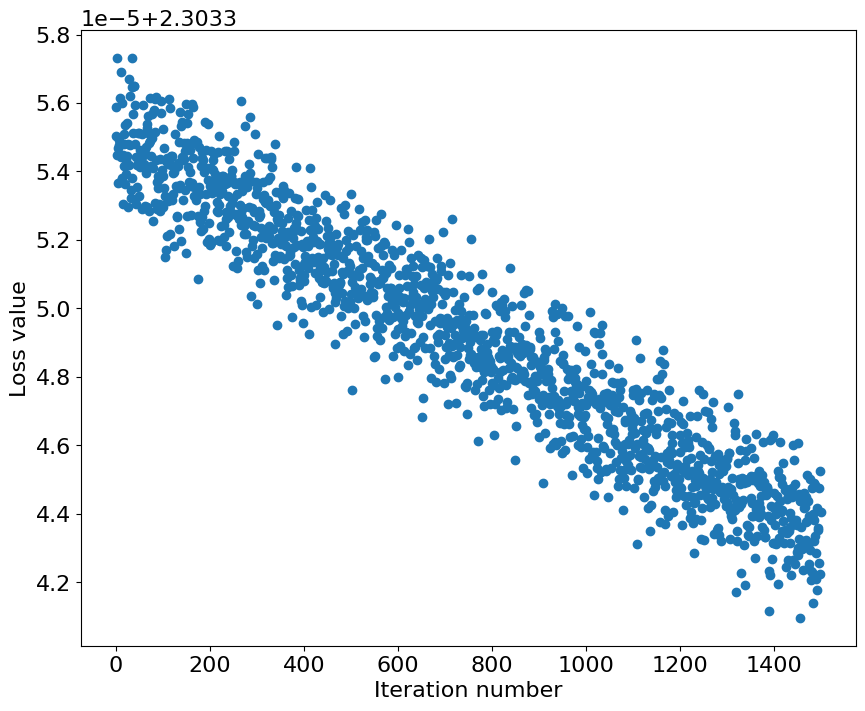

In [37]:
plt.plot(loss_hist, 'o')
plt.xlabel('Iteration number')
plt.ylabel('Loss value')
plt.show()

Let's compute the accuracy of current model. It should be less than 10%.  
让我们计算当前模型的准确性。它应该小于 10%。

In [38]:
import eecs598
from linear_classifier import predict_linear_classifier

eecs598.reset_seed(0)
# Reset random seed for reproducibility
# 固定随机种子，保证实验可复现

# evaluate the performance on both the training and validation set
# 在训练集和验证集上评估模型性能

# YOUR_TURN??: predict_linear_classifier should be same as what you've implemented before, in the SVM section
# 你的任务??: predict_linear_classifier 应该与之前在 SVM 部分实现的相同

y_train_pred = predict_linear_classifier(W, data_dict['X_train'])
# 使用训练好的权重 W 对训练集进行预测
train_acc = 100.0 * (data_dict['y_train'] == y_train_pred).double().mean().item()
# 计算训练集准确率
# (训练标签 == 预测标签) → bool tensor → 转为 double → 求平均 → 转为 Python float
print('training accuracy: %.2f%%' % train_acc)
# 打印训练集准确率

y_val_pred = predict_linear_classifier(W, data_dict['X_val'])
# 使用训练好的权重 W 对验证集进行预测
val_acc = 100.0 * (data_dict['y_val'] == y_val_pred).double().mean().item()
# 计算验证集准确率
print('validation accuracy: %.2f%%' % val_acc)
# 打印验证集准确率


training accuracy: 8.89%
validation accuracy: 8.54%


Now use the validation set to tune hyperparameters (regularization strength and learning rate). You should experiment with different ranges for the learning rates and regularization strengths.

To get full credit for the assignment, your best model found through cross-validation should achieve an accuracy above 0.37 on the validation set.

(Our best model was above 39.8% -- did you beat us?)          
现在使用验证集来调整超参数（正则化强度和学习率）。您应该尝试不同的学习率和正则化强度范围。

要获得分配的全部学分，通过交叉验证找到的最佳模型应在验证集上达到高于 0.37 的准确度。

（我们最好的模型在 39.8% 以上——你打败了我们吗？

In [40]:
import os
import eecs598
from linear_classifier import Softmax, softmax_get_search_params, test_one_param_set

# YOUR_TURN: find the best learning_rates and regularization_strengths combination
#            in 'softmax_get_search_params'
# 你的任务: 在 'softmax_get_search_params' 中找到最佳学习率和正则化强度组合
learning_rates, regularization_strengths = softmax_get_search_params()
num_models = len(learning_rates) * len(regularization_strengths)
# 计算总共要测试的模型组合数量

####
# It is okay to comment out the following conditions when you are working on svm_get_search_params.
# But, please do not forget to reset back to the original setting once you are done.
# 在调试 svm_get_search_params 时可以注释下面的条件
# 但完成后请恢复原设置
if num_models > 25:
  raise Exception("Please do not test/submit more than 25 items at once")
elif num_models < 5:
  raise Exception("Please present at least 5 parameter sets in your final ipynb")
# 检查参数组合数量，确保测试数目合理

i = 0
# As before, store your cross-validation results in this dictionary.
# The keys should be tuples of (learning_rate, regularization_strength) and
# the values should be tuples (train_acc, val_acc)
# 像之前一样，用字典存储交叉验证结果
# key: (learning_rate, regularization_strength)
# value: (train_acc, val_acc)
results = {}

best_val = -1.0   # The highest validation accuracy that we have seen so far.
# 当前看到的最佳验证集准确率
best_softmax_model = None # The Softmax object that achieved the highest validation rate.
# 对应最佳验证准确率的 Softmax 模型对象
num_iters = 2000 # number of iterations
# 训练迭代次数

for lr in learning_rates:
  for reg in regularization_strengths:
    i += 1
    print('Training Softmax %d / %d with learning_rate=%e and reg=%e'
          % (i, num_models, lr, reg))
    # 打印当前训练进度和参数组合

    eecs598.reset_seed(0)
    # Reset random seed for reproducibility
    # 固定随机种子保证实验可复现
    cand_softmax_model, cand_train_acc, cand_val_acc = test_one_param_set(
        Softmax(), data_dict, lr, reg, num_iters)
    # 测试当前参数组合
    # 返回训练好的模型以及训练和验证准确率

    if cand_val_acc > best_val:
      best_val = cand_val_acc
      best_softmax_model = cand_softmax_model # save the classifier
      # 如果当前验证准确率更高，则更新最佳模型
    results[(lr, reg)] = (cand_train_acc, cand_val_acc)
    # 将当前参数组合的训练和验证准确率存入字典

# Print out results.
# 输出所有组合的结果
for lr, reg in sorted(results):
  train_acc, val_acc = results[(lr, reg)]
  print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
         lr, reg, train_acc, val_acc))
    
print('best validation accuracy achieved during cross-validation: %f' % best_val)
# 输出交叉验证期间取得的最佳验证集准确率

# save the best model
# 保存最佳模型
path = os.path.join(os.getcwd(), 'softmax_best_model.pt')
best_softmax_model.save(path)


Training Softmax 1 / 25 with learning_rate=1.000000e-04 and reg=1.000000e-05
Training Softmax 2 / 25 with learning_rate=1.000000e-04 and reg=1.000000e-04
Training Softmax 3 / 25 with learning_rate=1.000000e-04 and reg=1.000000e-03
Training Softmax 4 / 25 with learning_rate=1.000000e-04 and reg=1.000000e-02
Training Softmax 5 / 25 with learning_rate=1.000000e-04 and reg=1.000000e-01
Training Softmax 6 / 25 with learning_rate=3.000000e-04 and reg=1.000000e-05
Training Softmax 7 / 25 with learning_rate=3.000000e-04 and reg=1.000000e-04
Training Softmax 8 / 25 with learning_rate=3.000000e-04 and reg=1.000000e-03
Training Softmax 9 / 25 with learning_rate=3.000000e-04 and reg=1.000000e-02
Training Softmax 10 / 25 with learning_rate=3.000000e-04 and reg=1.000000e-01
Training Softmax 11 / 25 with learning_rate=1.000000e-03 and reg=1.000000e-05
Training Softmax 12 / 25 with learning_rate=1.000000e-03 and reg=1.000000e-04
Training Softmax 13 / 25 with learning_rate=1.000000e-03 and reg=1.000000

Run the following to visualize your cross-validation results:

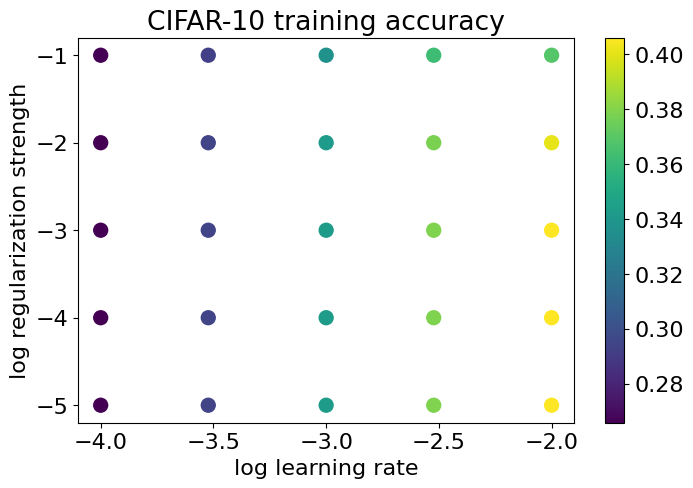

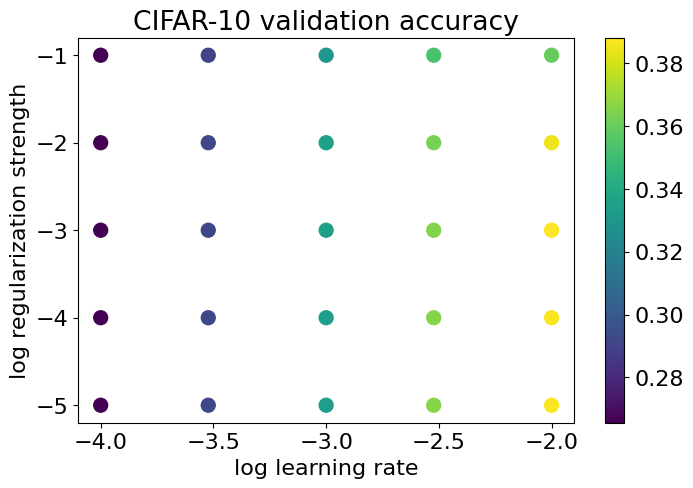

In [41]:
x_scatter = [math.log10(x[0]) for x in results]
y_scatter = [math.log10(x[1]) for x in results]

# plot training accuracy
marker_size = 100
colors = [results[x][0] for x in results]
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap='viridis')
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 training accuracy')
plt.gcf().set_size_inches(8, 5)
plt.show()

# plot validation accuracy
colors = [results[x][1] for x in results] # default size of markers is 20
plt.scatter(x_scatter, y_scatter, marker_size, c=colors, cmap='viridis')
plt.colorbar()
plt.xlabel('log learning rate')
plt.ylabel('log regularization strength')
plt.title('CIFAR-10 validation accuracy')
plt.gcf().set_size_inches(8, 5)
plt.show()

Them, evaluate the performance of your best model on test set. To get full credit for this assignment you should achieve a test-set accuracy above 0.36.

(Our best was just around 39.9% -- did you beat us?)



In [42]:
y_test_pred = best_softmax_model.predict(data_dict['X_test'])
test_accuracy = torch.mean((data_dict['y_test'] == y_test_pred).double())
print('softmax on raw pixels final test set accuracy: %f' % (test_accuracy, ))

softmax on raw pixels final test set accuracy: 0.394700


Finally, let's visualize the learned weights for each class

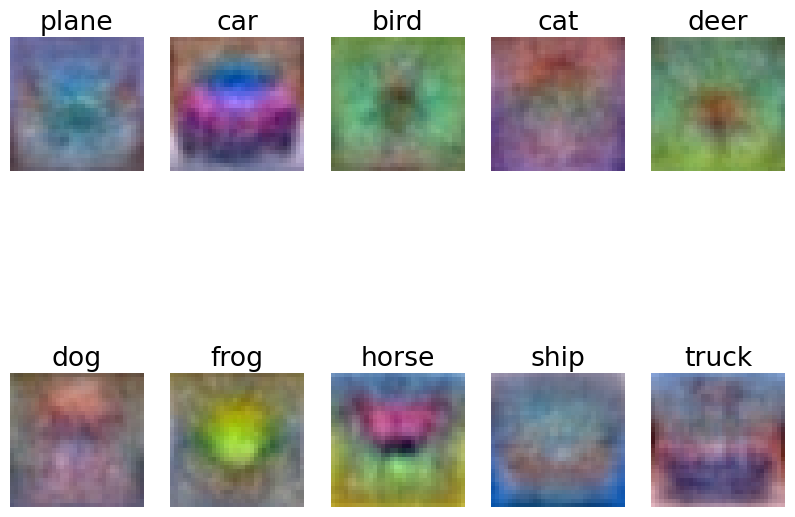

In [43]:
w = best_softmax_model.W[:-1,:] # strip out the bias
w = w.reshape(3, 32, 32, 10)
w = w.transpose(0, 2).transpose(1, 0)

w_min, w_max = torch.min(w), torch.max(w)

classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for i in range(10):
  plt.subplot(2, 5, i + 1)

  # Rescale the weights to be between 0 and 255
  wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
  plt.imshow(wimg.type(torch.uint8).cpu())
  plt.axis('off')
  plt.title(classes[i])